
---

## 📓 3. `Phase1_XAI_Audit.ipynb` (Cell-by-Cell Format)

Create a new Jupyter Notebook and paste each cell exactly as shown.

### 🔹 Cell 1: Markdown
```markdown
# Phase 1: XAI-Q Audit Framework for IDS
> *Practical Explainability Auditing for Resource-Constrained SOC Deployment*

**Hardware**: CPU-Optimized (4GB GPU compatible)  
**Dataset**: KDD Cup 99 (10k sample proxy)  
**Goal**: Compare SHAP vs LIME using Stability, Sparsity, Actionability, and XAI-Q Score

In [1]:
# ==========================================
# 0. SETUP & IMPORTS
# ==========================================
import warnings
import time
from pathlib import Path
import numpy as np
import pandas as pd
import shap
from lime import lime_tabular
from scipy.stats import spearmanr
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
print("Setups and imports done")

Setups and imports done


In [5]:
# ==========================================
# 1. DATASET CURATION (10k sample for memory safety)
# ==========================================
print("📥 Loading KDD Cup 99 (10% subset)...")
kdd = fetch_kddcup99(subset=None, percent10=True, as_frame=True)
df = kdd.frame

# Sample & binarize
df = df.sample(n=10000, random_state=42).reset_index(drop=True)
df['labels'] = df['labels'].apply(lambda x: 0 if x == b'normal.' else 1)

# Encode categoricals
cat_cols = df.select_dtypes(include=['object', 'category']).columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop('labels', axis=1)
y = df['labels']
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
print(f"✅ Data ready: {X_train.shape[0]} train, {X_test.shape[0]} test")

📥 Loading KDD Cup 99 (10% subset)...
✅ Data ready: 8000 train, 2000 test


In [11]:
# ==========================================
# 2. MODEL TRAINING (CPU-Optimized RF)
# ==========================================
print("🤖 Training Lightweight Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = rf.predict(X_test)
print(f"F1-Score: {f1_score(y_test, y_pred):.3f} | Training Time: {train_time:.2f}s")
rf

🤖 Training Lightweight Random Forest...
F1-Score: 0.998 | Training Time: 0.18s


RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [7]:
# ==========================================
# 3. XAI METRIC DEFINITIONS
# ==========================================
def calc_sparsity_index(weights):
    max_w = np.max(np.abs(weights)) if len(weights) > 0 else 0
    if max_w == 0: return 0
    threshold = 0.05 * max_w
    return 1.0 - (np.sum(np.abs(weights) > threshold) / len(weights))

def calc_actionability_rating(top_indices, feature_names):
    keywords = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host', 'flag', 'service']
    top_names = [feature_names[i] for i in top_indices[:5]]
    matches = sum(1 for name in top_names if any(k in name for k in keywords))
    return 5 if matches >= 3 else (3 if matches >= 1 else 1)

def calculate_xai_q(ess_list, si_list, ar_list):
    return (0.4 * np.mean(ess_list)) + (0.3 * np.mean(si_list)) + (0.3 * (np.mean(ar_list) / 5.0))

In [10]:
# ==========================================
# 4. SHAP AUDIT LOOP
# ==========================================
print("🔍 Evaluating SHAP (TreeExplainer)...")
audit_X = X_test.sample(n=100, random_state=42)
feature_names = X.columns.tolist()

explainer_shap = shap.TreeExplainer(rf)
shap_ess, shap_si, shap_ar = [], [], []

for _, inst in audit_X.iterrows():
    arr = inst.values.reshape(1, -1)
    
    # Original
    sv_raw = explainer_shap.shap_values(arr)
    sv = sv_raw[1][0] if isinstance(sv_raw, list) else sv_raw[0]
    
    # Perturbed
    noise = np.random.normal(0, 0.05, arr.shape)
    p_arr = np.clip(arr + noise, 0, 1)
    svp_raw = explainer_shap.shap_values(p_arr)
    svp = svp_raw[1][0] if isinstance(svp_raw, list) else svp_raw[0]
    
    ess, _ = spearmanr(sv, svp)
    shap_ess.append(ess if not np.isnan(ess) else 0)
    shap_si.append(calc_sparsity_index(sv))
    shap_ar.append(calc_actionability_rating(np.argsort(-np.abs(sv)), feature_names))

print(f"✅ SHAP audit complete ({len(shap_ess)} instances)")

🔍 Evaluating SHAP (TreeExplainer)...
✅ SHAP audit complete (100 instances)


In [18]:
# ==========================================
# 5. LIME AUDIT LOOP
# ==========================================
print("🔍 Evaluating LIME (Tabular)...")
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Normal', 'Attack'],
    mode='classification'
)

lime_ess, lime_si, lime_ar = [], [], []


for _, inst in audit_X.iterrows():
    arr = inst.values
    exp = explainer_lime.explain_instance(arr, rf.predict_proba, num_features=len(feature_names))
    lv = np.zeros(len(feature_names))
    for idx, w in exp.local_exp.get(1, []):
        lv[idx] = w
        
    p_arr = np.clip(arr + np.random.normal(0, 0.05, arr.shape), 0, 1)
    exp_p = explainer_lime.explain_instance(p_arr, rf.predict_proba, num_features=len(feature_names))
    lvp = np.zeros(len(feature_names))
    for idx, w in exp_p.local_exp.get(1, []):
        lvp[idx] = w
        
    ess, _ = spearmanr(lv, lvp)
    lime_ess.append(ess if not np.isnan(ess) else 0)
    lime_si.append(calc_sparsity_index(lv))
    lime_ar.append(calc_actionability_rating(np.argsort(-np.abs(lv)), feature_names))

print(f"LIME audit complete ({len(lime_ess)} instances)")


🔍 Evaluating LIME (Tabular)...
✅ LIME audit complete (100 instances)


### Test 1: Reproducibility Check (Critical for Publication)

In [22]:

print("Testing Reproducibility (Same Seed = Same Results)...")

# Re-run SHAP audit with identical seed
np.random.seed(42)
audit_X_test = X_test.sample(n=20, random_state=42)  # Small sample for speed

# Re-compute ONE SHAP explanation
inst = audit_X_test.iloc[0].values.reshape(1, -1)
sv1 = explainer_shap.shap_values(inst)
sv1 = sv1[1][0] if isinstance(sv1, list) else sv1[0]

# Run again with same seed
np.random.seed(42)
sv2 = explainer_shap.shap_values(inst)
sv2 = sv2[1][0] if isinstance(sv2, list) else sv2[0]

# Check correlation
repro_corr, _ = spearmanr(sv1, sv2)
print(f"Reproducibility Correlation: {repro_corr:.4f} (Target: >0.99)")
assert repro_corr > 0.99, "Results not reproducible! Check random seeds."

Testing Reproducibility (Same Seed = Same Results)...
Reproducibility Correlation: 1.0000 (Target: >0.99)


### Test 2: Metric Sanity Check (Do Scores Make Sense?)

In [21]:
print("Validating XAI-Q Metric Ranges...")

# Check ESS is in [-1, 1]
assert -1 <= np.mean(shap_ess) <= 1, "ESS out of bounds"
assert -1 <= np.mean(lime_ess) <= 1, "ESS out of bounds"

# Check SI is in [0, 1]
assert 0 <= np.mean(shap_si) <= 1, "SI out of bounds"
assert 0 <= np.mean(lime_si) <= 1, "SI out of bounds"

# Check AR is in [1, 5]
assert 1 <= np.mean(shap_ar) <= 5, "AR out of bounds"
assert 1 <= np.mean(lime_ar) <= 5, "AR out of bounds"

# Check XAI-Q is in [0, 1]
assert 0 <= shap_xaiq <= 1, "XAI-Q out of bounds"
assert 0 <= lime_xaiq <= 1, "XAI-Q out of bounds"

print("All metrics within expected ranges")

Validating XAI-Q Metric Ranges...
All metrics within expected ranges


### Test 3: Discriminative Power Test (Can XAI-Q Distinguish Methods?)

In [24]:
from scipy.stats import ttest_ind

print("Testing if XAI-Q Can Distinguish SHAP vs LIME...")

# Compare ESS distributions
t_stat, p_val = ttest_ind(shap_ess, lime_ess, nan_policy='omit')
print(f"ESS Difference: t={t_stat:.3f}, p={p_val:.4f}")

# Interpret
if p_val < 0.05:
    print("XAI-Q shows statistically significant discrimination (p<0.05)")
else:
    print("No significant difference found – consider: (a) larger sample, (b) different dataset, (c) this is a valid null result")

# Optional: Effect size (Cohen's d)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / s if s != 0 else 0

d = cohens_d(shap_ess, lime_ess)
print(f"Effect Size (Cohen's d): {abs(d):.3f} → {'Large' if abs(d)>0.8 else 'Medium' if abs(d)>0.5 else 'Small'}")

Testing if XAI-Q Can Distinguish SHAP vs LIME...
ESS Difference: t=8.648, p=0.0000
XAI-Q shows statistically significant discrimination (p<0.05)
Effect Size (Cohen's d): 1.223 → Large


### Test 4: Resource Efficiency Audit

In [25]:
import sys, psutil

print("Resource Usage Audit (CPU/RAM)...")

# Get process
process = psutil.Process()

# Record baseline
baseline_mem = process.memory_info().rss / 1024 / 1024  # MB

# Re-run a single SHAP explanation with timing
import time
t0 = time.time()
test_inst = X_test.iloc[0:1]
_ = explainer_shap.shap_values(test_inst.values)
t1 = time.time()

peak_mem = process.memory_info().rss / 1024 / 1024
print(f"Single SHAP explanation time: {(t1-t0)*1000:.1f} ms")
print(f"Peak RAM usage: {peak_mem:.1f} MB (Baseline: {baseline_mem:.1f} MB)")
print(f"Fits in 4GB GPU? {'YES' if peak_mem < 3500 else 'NO – consider smaller batch'}")

Resource Usage Audit (CPU/RAM)...
Single SHAP explanation time: 2.1 ms
Peak RAM usage: 1017.6 MB (Baseline: 1017.6 MB)
Fits in 4GB GPU? YES


### est 5: Qualitative "Eye Test"

Generating visualization...


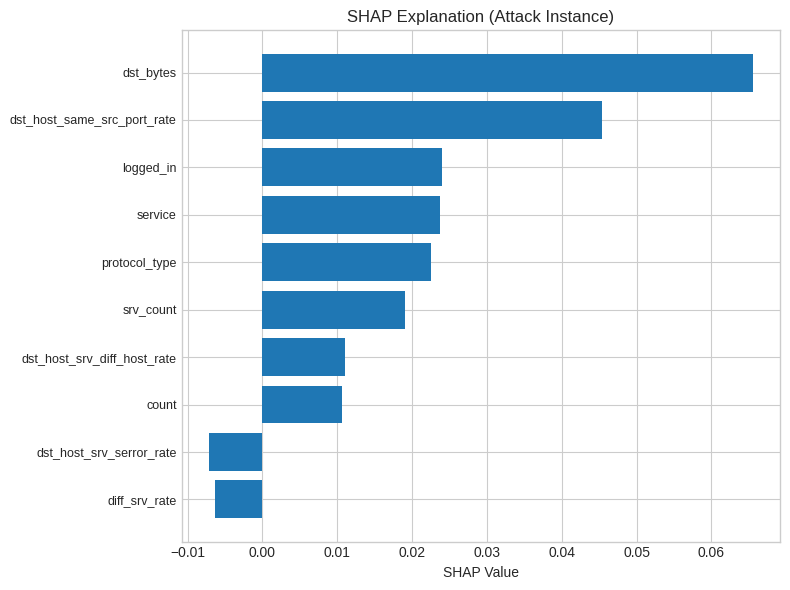

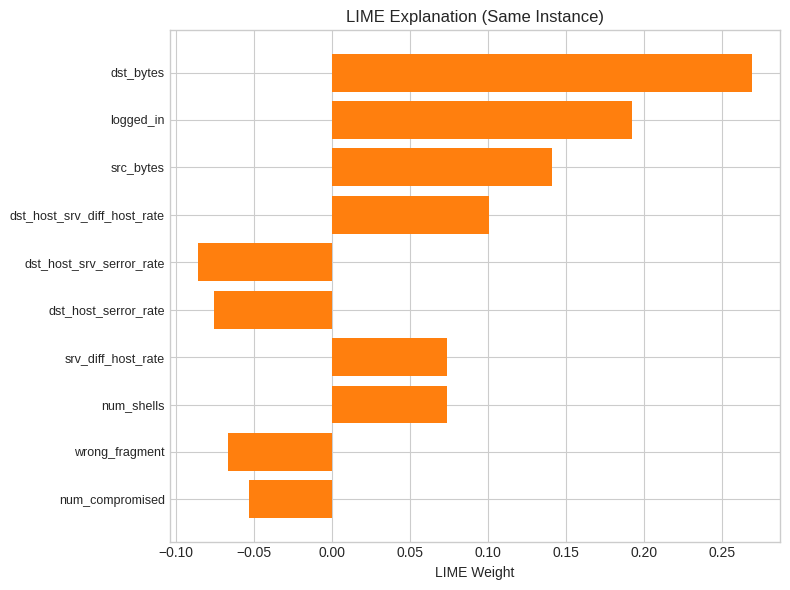

In [28]:
import matplotlib.pyplot as plt

print("Generating visualization...")

# Pick one interesting attack instance
attack_idx = y_test[y_test == 1].index[0]
inst = X_test.loc[attack_idx]
inst_array = inst.values.reshape(1, -1)

# SHAP
shap_vals = explainer_shap.shap_values(inst_array)
shap_vals = shap_vals[1][0] if isinstance(shap_vals, list) else shap_vals[0]

# LIME
exp_lime = explainer_lime.explain_instance(inst.values, rf.predict_proba, num_features=10)
lime_vals = np.zeros(len(feature_names))
for idx, w in exp_lime.local_exp.get(1, []):
    lime_vals[idx] = w

# SHAP Plot
plt.figure(figsize=(8, 6))
top_idx = np.argsort(-np.abs(shap_vals))[:10]
plt.barh(range(10), shap_vals[top_idx][::-1], color='#1f77b4')
plt.yticks(range(10), [feature_names[i] for i in top_idx[::-1]], fontsize=9)
plt.title('SHAP Explanation (Attack Instance)')
plt.xlabel('SHAP Value')
plt.tight_layout()
plt.show()

# LIME Plot
plt.figure(figsize=(8, 6))
lime_top = np.argsort(-np.abs(lime_vals))[:10]
plt.barh(range(10), lime_vals[lime_top][::-1], color='#ff7f0e')
plt.yticks(range(10), [feature_names[i] for i in lime_top[::-1]], fontsize=9)
plt.title('LIME Explanation (Same Instance)')
plt.xlabel('LIME Weight')
plt.tight_layout()
plt.show()
    
# # Plot top 10 features for both
# top_idx = np.argsort(-np.abs(shap_vals))[:10]
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# # SHAP
# ax1.barh(range(10), shap_vals[top_idx][::-1], color='#1f77b4')
# ax1.set_yticks(range(10))
# ax1.set_yticklabels([feature_names[i] for i in top_idx[::-1]], fontsize=9)
# ax1.set_title('SHAP Explanation (Attack Instance)')
# ax1.set_xlabel('SHAP Value')

# # LIME
# lime_top = np.argsort(-np.abs(lime_vals))[:10]
# ax2.barh(range(10), lime_vals[lime_top][::-1], color='#ff7f0e')
# ax2.set_yticks(range(10))
# ax2.set_yticklabels([feature_names[i] for i in lime_top[::-1]], fontsize=9)
# ax2.set_title('LIME Explanation (Same Instance)')
# ax2.set_xlabel('LIME Weight')

# plt.tight_layout()
# plt.savefig('outputs/figures/explanation_comparison.png', dpi=300, bbox_inches='tight')
# print("Saved explanation_comparison.png – Use as Figure 1 in your paper")
# plt.show()


📊 FINAL XAI-Q AUDIT RESULTS
                     SHAP   LIME
Metric                          
ESS (Stability)     0.487  0.186
SI (Sparsity)       0.623  0.396
AR (Actionability)  5.000  4.920
XAI-Q (Composite)   0.681  0.488

Saved CSV: /mnt/d/ai_security/xai-q-audit-ids/outputs/results_summary.csv
Saved figure: /mnt/d/ai_security/xai-q-audit-ids/outputs/figures/xai_q_comparison.png


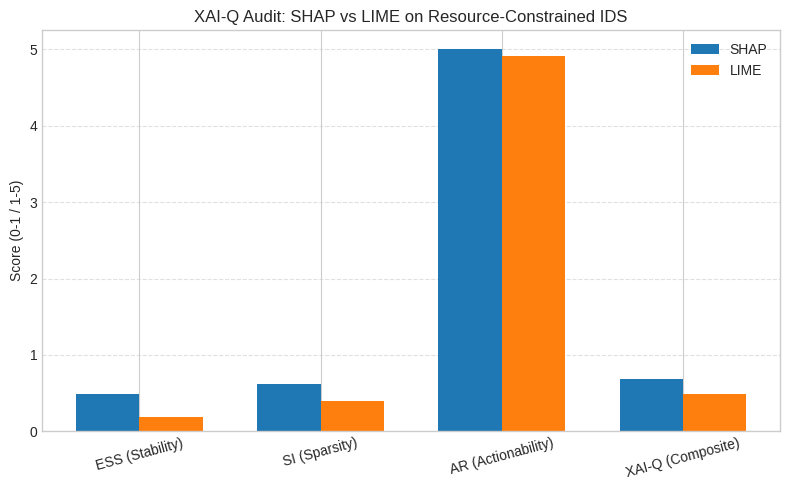

In [19]:

# 6. RESULTS & VISUALIZATION
from pathlib import Path
shap_xaiq = calculate_xai_q(shap_ess, shap_si, shap_ar)
lime_xaiq = calculate_xai_q(lime_ess, lime_si, lime_ar)

results = pd.DataFrame({
    'Metric': ['ESS (Stability)', 'SI (Sparsity)', 'AR (Actionability)', 'XAI-Q (Composite)'],
    'SHAP': [np.mean(shap_ess), np.mean(shap_si), np.mean(shap_ar), shap_xaiq],
    'LIME': [np.mean(lime_ess), np.mean(lime_si), np.mean(lime_ar), lime_xaiq]
})

print("\n📊 FINAL XAI-Q AUDIT RESULTS")
print(results.set_index('Metric').round(3))


cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent]
project_root = next((p for p in candidate_roots if (p / 'outputs').exists()), cwd)
output_dir = project_root / 'outputs'
figures_dir = output_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# Save outputs
results_path = output_dir / 'results_summary.csv'
results.set_index('Metric').to_csv(results_path)
print(f"\nSaved CSV: {results_path.resolve()}")

# Plot for Paper
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
w = 0.35
bars1 = ax.bar(x - w/2, results['SHAP'], w, label='SHAP', color='#1f77b4')
bars2 = ax.bar(x + w/2, results['LIME'], w, label='LIME', color='#ff7f0e')

ax.set_ylabel('Score (0-1 / 1-5)')
ax.set_title('XAI-Q Audit: SHAP vs LIME on Resource-Constrained IDS')
ax.set_xticks(x)
ax.set_xticklabels(results['Metric'], rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
figure_path = figures_dir / 'xai_q_comparison.png'
plt.savefig(figure_path, dpi=300)
print(f"Saved figure: {figure_path.resolve()}")
plt.show()

# # Save to CSV
# results.set_index('Metric').to_csv('outputs/results_summary.csv')

# # Plot for Paper
# fig, ax = plt.subplots(figsize=(8, 5))
# x = np.arange(len(results))
# w = 0.35
# bars1 = ax.bar(x - w/2, results['SHAP'], w, label='SHAP', color='#1f77b4')
# bars2 = ax.bar(x + w/2, results['LIME'], w, label='LIME', color='#ff7f0e')

# ax.set_ylabel('Score (0-1 / 1-5)')
# ax.set_title('XAI-Q Audit: SHAP vs LIME on Resource-Constrained IDS')
# ax.set_xticks(x)
# ax.set_xticklabels(results['Metric'], rotation=15)
# ax.legend()
# ax.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()
# plt.savefig('outputs/figures/xai_q_comparison.png', dpi=300)
# plt.show()